<a href="https://colab.research.google.com/github/doa-2026/machine-learning/blob/main/fetal_health_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fetal Health Classification
**Target:** `fetal_health` — 1 (Normal), 2 (Suspect), 3 (Pathological)  
**Task:** Multiclass classification using a Keras neural network  
**Data:** 2126 rows, 21 features, no missing values

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Keras
from tensorflow.keras import Sequential
from tensorflow.keras import metrics
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, LabelBinarizer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

## 2. Helper Functions

In [ ]:
def classification_metrics(y_true, y_pred, label='', figsize=(10, 4),
                           normalize='true', cmap='Blues', colorbar=False):
    report = classification_report(y_true, y_pred,
                                   target_names=['Normal', 'Suspect', 'Pathological'])
    header = "-" * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    fig, axes = plt.subplots(ncols=2, figsize=figsize)
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, normalize=None, cmap='gist_gray',
        values_format='d', colorbar=colorbar, ax=axes[0],
        display_labels=['Normal', 'Suspect', 'Pathological'])
    axes[0].set_title('Raw Counts')

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, normalize=normalize, cmap=cmap,
        values_format='.2f', colorbar=colorbar, ax=axes[1],
        display_labels=['Normal', 'Suspect', 'Pathological'])
    axes[1].set_title('Normalized Confusion Matrix')

    fig.tight_layout()
    plt.show()


def plot_history(history, figsize=(6, 12), marker='o'):
    metric_names = [c for c in history.history if not c.startswith('val_')]
    fig, axes = plt.subplots(nrows=len(metric_names), figsize=figsize)
    if len(metric_names) == 1:
        axes = [axes]
    for i, name in enumerate(metric_names):
        ax = axes[i]
        ax.plot(history.epoch, history.history[name], label=name, marker=marker)
        val_name = f'val_{name}'
        if val_name in history.history:
            ax.plot(history.epoch, history.history[val_name], label=val_name, marker=marker)
        ax.legend()
        ax.set_title(name)
    fig.tight_layout()
    return fig, axes

## 3. Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/Week19/Data/mortality_fetal_prediction.xlsx")
# Dropping unique IDs
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   int64  
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   int64  
 8   mean_value_of_short_term_variability  

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120,0.000,0.0,0.000,0.000,0.0,0.0,73,0.5,43,...,62,126,2,0,120,137,121,73,1,2
1,132,0.006,0.0,0.006,0.003,0.0,0.0,17,2.1,0,...,68,198,6,1,141,136,140,12,0,1
2,133,0.003,0.0,0.008,0.003,0.0,0.0,16,2.1,0,...,68,198,5,1,141,135,138,13,0,1
3,134,0.003,0.0,0.008,0.003,0.0,0.0,16,2.4,0,...,53,170,11,0,137,134,137,13,1,1
4,132,0.007,0.0,0.008,0.000,0.0,0.0,16,2.4,0,...,53,170,9,0,137,136,138,11,1,1


In [ ]:
print(df.info())
print(f'\nNull values: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   int64  
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   int64  
 8   mean_value_of_short_term_variability  

## 4. EDA

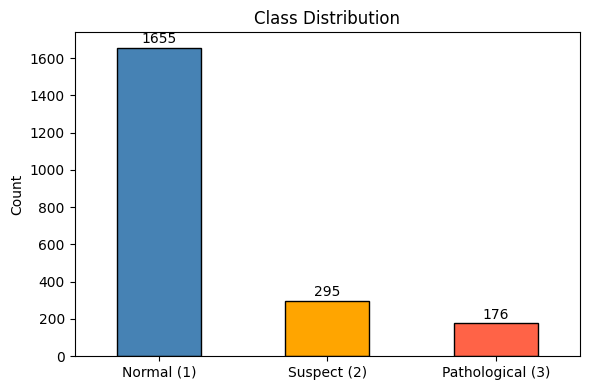


Class breakdown:
fetal_health
1    1655
2     295
3     176
Name: count, dtype: int64

Class imbalance: Normal dominates (~78%). Accuracy alone will be misleading.


In [ ]:
# Class distribution
counts = df['fetal_health'].value_counts().sort_index()
labels = ['Normal (1)', 'Suspect (2)', 'Pathological (3)']
counts.index = labels

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color=['steelblue', 'orange', 'tomato'], edgecolor='black')
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
ax.set_xticklabels(labels, rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            int(bar.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

print("\nClass breakdown:")
print(df['fetal_health'].value_counts())
print("\nClass imbalance: Normal dominates (~78%). Accuracy alone will be misleading.")

## 5. Preprocessing

In [ ]:
# Split features and target
X = df.drop(columns='fetal_health')
y = df['fetal_health']

# Train/test split — stratified to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (1700, 21), Test: (426, 21)


In [ ]:
# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [ ]:
# Encode target: original -> integer -> binarized (one-hot)
encoder = LabelEncoder()
encoder.fit(y_train)
y_train_enc = encoder.transform(y_train)
y_test_enc  = encoder.transform(y_test)
classes = encoder.classes_
print('Classes:', classes)  # [1.0, 2.0, 3.0] -> encoded as [0, 1, 2]

binarizer = LabelBinarizer()
binarizer.fit(y_train_enc)
y_train_bin = binarizer.transform(y_train_enc)
y_test_bin  = binarizer.transform(y_test_enc)

print('\nBinarized shape:', y_train_bin.shape)
print('Sample binarized rows:\n', y_train_bin[:4])

Classes: [1 2 3]

Binarized shape: (1700, 3)
Sample binarized rows:
 [[0 0 1]
 [1 0 0]
 [0 0 1]
 [1 0 0]]


## 6. Build Model

In [ ]:
input_shape = X_train_sc.shape[1]   # 21 features
num_classes = len(classes)          # 3 classes

print(f'Input shape: {input_shape}, Num classes: {num_classes}')

Input shape: 21, Num classes: 3


In [ ]:
def build_model():
    model = Sequential([
        Dense(64, input_dim=input_shape, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')   # softmax for multiclass
    ])
    model.compile(
        loss='categorical_crossentropy',           # required when target is one-hot
        optimizer='adam',
        metrics=['accuracy', metrics.Precision(), metrics.Recall()]
    )
    return model

model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,747 (30.26 KB)

 Trainable params: 7,747 (30.26 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_sc, y_train_bin,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

print(f'Stopped at epoch: {len(history.epoch)}')

Epoch 62: early stopping
Restoring model weights from the end of the best epoch: 47.
Stopped at epoch: 62


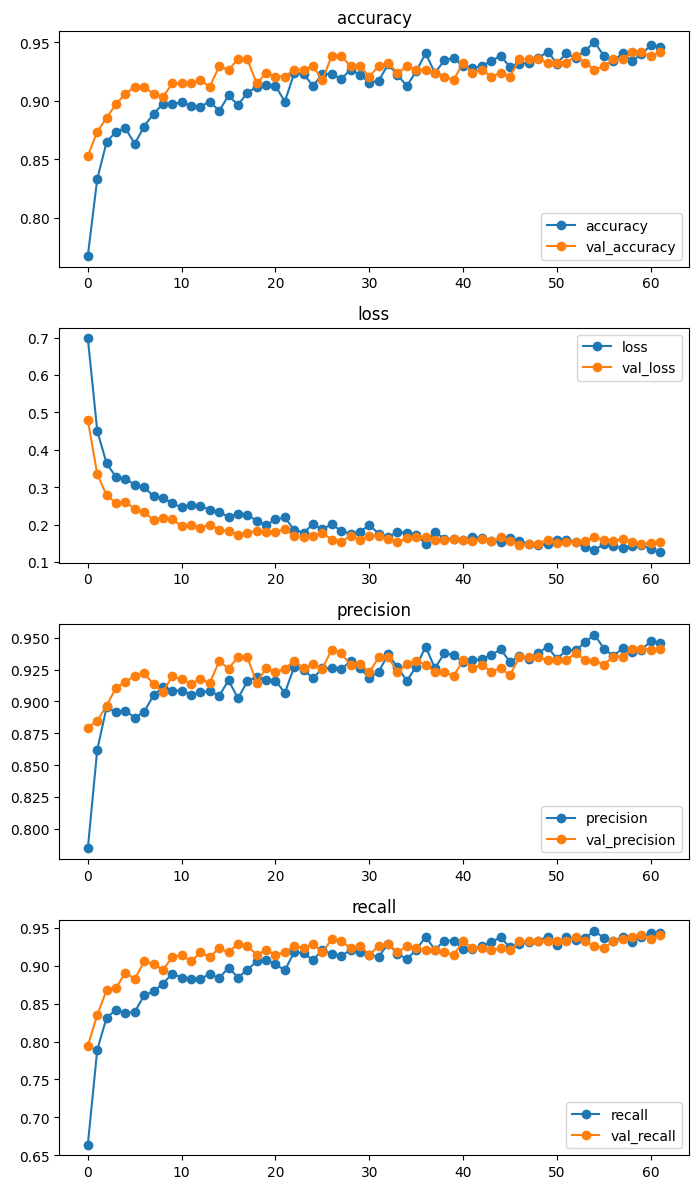

In [ ]:
plot_history(history, figsize=(7, 12));

## 8. Evaluate

In [ ]:
# Raw predictions -> softmax probabilities
raw_pred = model.predict(X_test_sc)

# Convert 2D probability arrays to 1D integer labels
y_pred = np.argmax(raw_pred, axis=1)
y_true = np.argmax(y_test_bin, axis=1)

print('Predictions:', y_pred[:10])
print('True labels:', y_true[:10])

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Predictions: [0 0 0 0 0 0 0 0 0 0]
True labels: [0 0 0 0 0 0 0 0 0 0]


----------------------------------------------------------------------
 Classification Metrics: Test Set
----------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.93      0.97      0.95       332
     Suspect       0.71      0.61      0.65        59
Pathological       0.90      0.74      0.81        35

    accuracy                           0.90       426
   macro avg       0.84      0.77      0.80       426
weighted avg       0.89      0.90      0.90       426



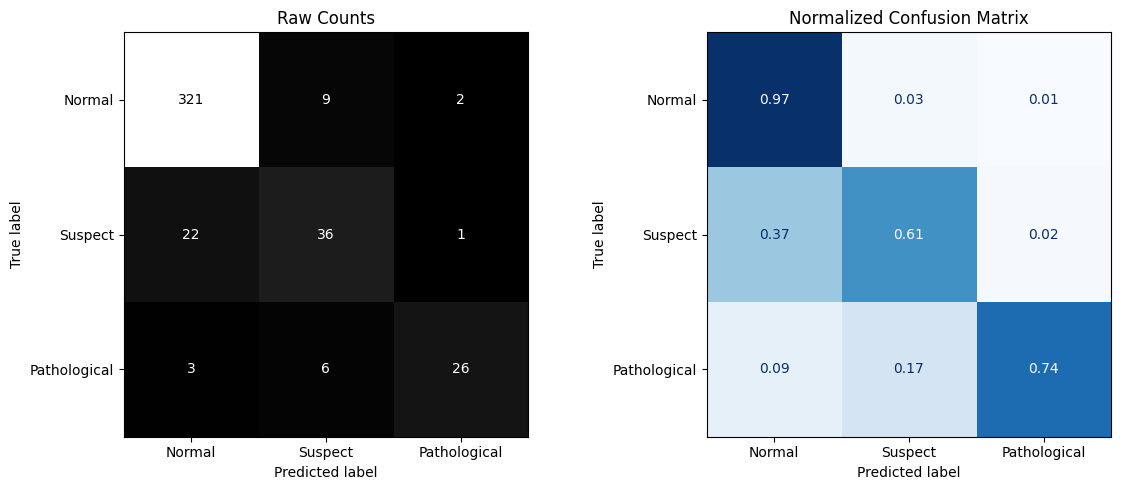

In [ ]:
classification_metrics(y_true, y_pred, label='Test Set', figsize=(12, 5))